# Method 1 — Base SCM (Reproduce Prior Work)

Fit the synthetic control weights for NATCOR using CAPE as donor pool. Report pre/post RMSPE, ratio, cumulative and average treatment effect.

In [1]:
import pandas as pd
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from numpy.linalg import lstsq
import warnings
warnings.filterwarnings('ignore')

# ── Helper functions ───────────────────────────────────────────────────────────
def fit_scm(Y_pre, X_pre):
    """Solve the constrained SCM weight optimisation problem (cvxpy)."""
    if X_pre.ndim == 1:
        X_pre = X_pre.reshape(-1, 1)
    n = X_pre.shape[1]
    w = cp.Variable(n)
    prob = cp.Problem(
        cp.Minimize(cp.sum_squares(Y_pre - X_pre @ w)),
        [w >= 0, cp.sum(w) == 1]
    )
    prob.solve(solver=cp.SCS)
    return np.array(w.value).flatten()

def rmspe(a, b):
    """Root Mean Squared Prediction Error."""
    return np.sqrt(np.mean((np.array(a) - np.array(b))**2))


## Data Preparation

In [4]:
# ── Data loading & shared objects ─────────────────────────────────────────────
df = pd.read_csv('./data/corridor.csv')
df['Date']        = df['Date'].astype(str).str.strip()
df['Corridor']    = df['Corridor'].astype(str).str.strip()
df['Date_period'] = pd.PeriodIndex(df['Date'], freq='M')

y_col       = 'Rail_Vol_mt'
treated     = 'NATCOR'
treat_start = pd.Period('2022-04', freq='M')
pre_end     = treat_start - 1

wide     = df.pivot(index='Date_period', columns='Corridor', values=y_col).sort_index()
donors   = [c for c in wide.columns if c != treated]
pre_idx  = wide.index[wide.index <= pre_end]
post_idx = wide.index[wide.index >= treat_start]
treat_t  = treat_start.to_timestamp()
t        = wide.index.to_timestamp()

# Fit base SCM (used by all methods)
w_hat  = fit_scm(wide.loc[pre_idx, treated].values,
                 wide.loc[pre_idx, donors].values)
synth  = pd.Series(wide[donors].values @ w_hat, index=wide.index, name='Synthetic')
actual = wide[treated]
gap    = actual - synth

base_pre_rmspe  = rmspe(actual[pre_idx], synth[pre_idx])
base_post_rmspe = rmspe(actual[post_idx], synth[post_idx])
base_ratio      = base_post_rmspe / base_pre_rmspe

print(f'Pre periods : {len(pre_idx)} ({pre_idx[0]} – {pre_idx[-1]})')
print(f'Post periods: {len(post_idx)} ({post_idx[0]} – {post_idx[-1]})')
print(f'Donors      : {donors}')
print(f'Base SCM Pre-RMSPE  : {base_pre_rmspe:.4f}')
print(f'Base SCM Post-RMSPE : {base_post_rmspe:.4f}')
print(f'Base SCM Ratio      : {base_ratio:.4f}')


Pre periods : 87 (2015-01 – 2022-03)
Post periods: 33 (2022-04 – 2024-12)
Donors      : ['CAPE']
Base SCM Pre-RMSPE  : 0.2132
Base SCM Post-RMSPE : 0.3653
Base SCM Ratio      : 1.7140


## SCM Estimation & Key Metrics

In [5]:
# ── Method 1 : Base SCM ────────────────────────────────────────────────────────
cum_eff = gap[post_idx].sum()
avg_eff = gap[post_idx].mean()

print(f'Weights      : {dict(zip(donors, w_hat.round(4)))}')
print(f'Pre-RMSPE    : {base_pre_rmspe:.4f}')
print(f'Post-RMSPE   : {base_post_rmspe:.4f}')
print(f'Ratio        : {base_ratio:.4f}')
print(f'Cumul effect : {cum_eff:.4f} MT')
print(f'Avg monthly  : {avg_eff:.4f} MT/month')


Weights      : {'CAPE': np.float64(1.0)}
Pre-RMSPE    : 0.2132
Post-RMSPE   : 0.3653
Ratio        : 1.7140
Cumul effect : -11.1040 MT
Avg monthly  : -0.3365 MT/month


## Figure 1 — Actual vs Synthetic Counterfactual

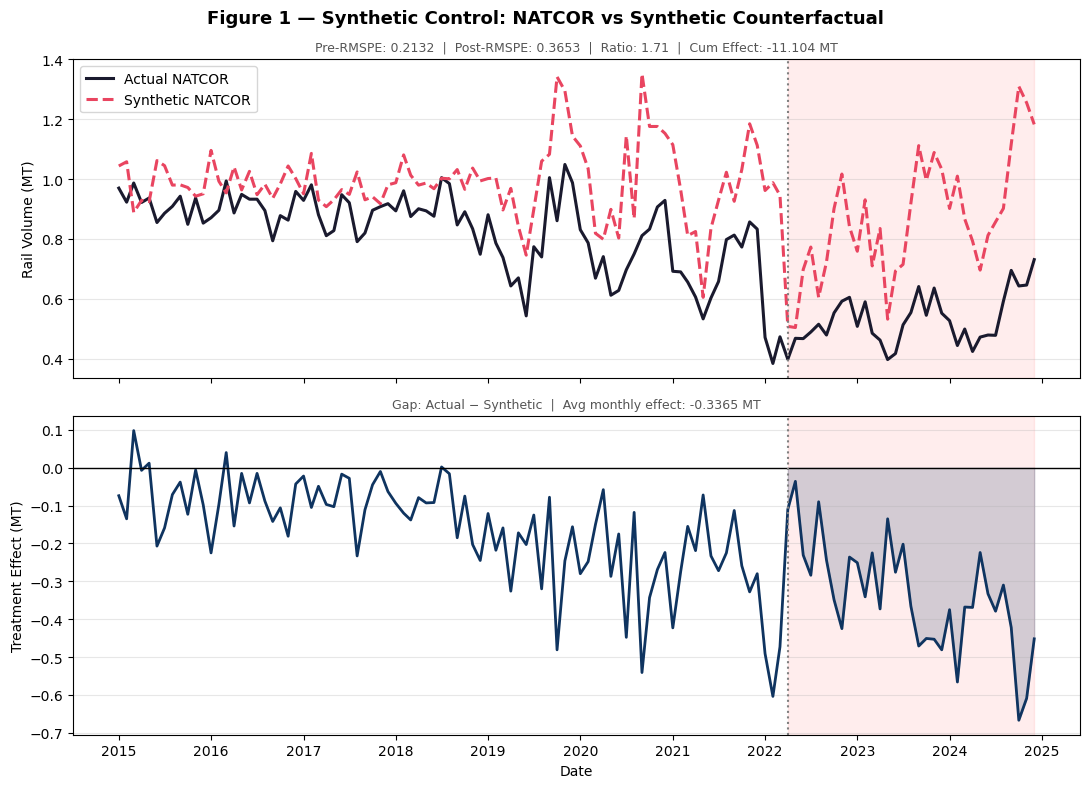

Figure saved → fig1_base_scm.png


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
fig.suptitle('Figure 1 — Synthetic Control: NATCOR vs Synthetic Counterfactual',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(t, actual.values, color='#1a1a2e', lw=2.2, label='Actual NATCOR')
ax.plot(t, synth.values,  color='#e94560', lw=2.2, ls='--', label='Synthetic NATCOR')
ax.axvline(treat_t, color='grey', lw=1.5, ls=':')
ax.axvspan(treat_t, t[-1], alpha=0.07, color='red')
ax.set_ylabel('Rail Volume (MT)')
ax.legend()
ax.set_title(
    f'Pre-RMSPE: {base_pre_rmspe:.4f}  |  Post-RMSPE: {base_post_rmspe:.4f}'
    f'  |  Ratio: {base_ratio:.2f}  |  Cum Effect: {gap[post_idx].sum():.3f} MT',
    fontsize=9, color='#555')
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.plot(t, gap.values, color='#0f3460', lw=2)
ax.axhline(0, color='black', lw=1)
ax.axvline(treat_t, color='grey', lw=1.5, ls=':')
ax.axvspan(treat_t, t[-1], alpha=0.07, color='red')
ax.fill_between(t, gap.values, 0, where=(wide.index >= treat_start), alpha=0.18, color='#0f3460')
ax.set_ylabel('Treatment Effect (MT)')
ax.set_xlabel('Date')
ax.set_title(f'Gap: Actual − Synthetic  |  Avg monthly effect: {gap[post_idx].mean():.4f} MT',
             fontsize=9, color='#555')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_base_scm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → fig1_base_scm.png')
